# SETUP LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('data.xlsx')
print(df.columns)
print(df.head())

df_selected = df[['time', 'AA03 (21.175) ConnectorR Ave. (C)', 'AA03 (21.175) Middle Ave. (C)', 'AA03 (21.175) ConnectorL Ave. (C)', 
                  'AA03 (21.174) ConnectorR Ave. (C)', 'AA03 (21.174) Middle Ave. (C)', 'AA03 (21.174) ConnectorL Ave. (C)',
                  'Uncoated ConnectorR Ave. (C)', 'Uncoated middle Ave. (C)', 'Uncoated ConnectorL Ave. (C)',
                  'AA03 (23.10) ConnectorR Ave. (C)', 'AA03 (23.10) middle Ave. (C)', 'AA03 (23.10) ConnectorL Ave. (C)', 'Ambient Ave. (C)']]

Index(['Index', 'time', 'Jumper 2 Last (C)', 'Jumper 2 Ave. (C)',
       'Jumper 2 Min. (C)', 'Jumper 2 Max. (C)',
       'AA03 (21.175) ConnectorR Ave. (C)', 'AA03 (21.175) Middle Ave. (C)',
       'AA03 (21.175) ConnectorL Ave. (C)', 'Jumper 3 Last (C)',
       'Jumper 3 Ave. (C)', 'Jumper 3 Min. (C)', 'Jumper 3 Max. (C)',
       'AA03 (21.174) ConnectorL Ave. (C)', 'AA03 (21.174) Middle Ave. (C)',
       'diff_174', 'AA03 (21.174) ConnectorR Ave. (C)',
       'Uncoated ConnectorR Ave. (C)', 'Uncoated middle Ave. (C)',
       'Uncoated ConnectorL Ave. (C)', 'Jumper 1 Last (C)',
       'Jumper 1 Ave. (C)', 'Jumper 1 Min. (C)', 'Jumper 1 Max. (C)',
       'AA03 (23.10) ConnectorR Ave. (C)', 'AA03 (23.10) middle Ave. (C)',
       'AA03 (23.10) ConnectorL Ave. (C)', 'Ambient Last (C)',
       'Ambient Ave. (C)', 'Ambient Min. (C)', 'Ambient Max. (C)'],
      dtype='object')
   Index      time  Jumper 2 Last (C)  Jumper 2 Ave. (C)  Jumper 2 Min. (C)  \
0      1  00:00:00             55.77

In [20]:
df_selected = df[['time', 'AA03 (21.175) ConnectorR Ave. (C)', 'AA03 (21.175) Middle Ave. (C)', 'AA03 (21.175) ConnectorL Ave. (C)', 
                  'AA03 (21.174) ConnectorR Ave. (C)', 'AA03 (21.174) Middle Ave. (C)', 'AA03 (21.174) ConnectorL Ave. (C)',
                  'Uncoated ConnectorR Ave. (C)', 'Uncoated middle Ave. (C)', 'Uncoated ConnectorL Ave. (C)',
                  'AA03 (23.10) ConnectorR Ave. (C)', 'AA03 (23.10) middle Ave. (C)', 'AA03 (23.10) ConnectorL Ave. (C)', 'Ambient Ave. (C)']]

In [21]:
print(df_selected.head())
print(df_selected.columns)

       time  AA03 (21.175) ConnectorR Ave. (C)  AA03 (21.175) Middle Ave. (C)  \
0  00:00:00                             52.204                         60.267   
1  00:00:01                             52.273                         60.440   
2  00:00:02                             52.403                         60.670   
3  00:00:03                             52.515                         60.918   
4  00:00:04                             52.350                         61.137   

   AA03 (21.175) ConnectorL Ave. (C)  AA03 (21.174) ConnectorR Ave. (C)  \
0                             44.634                             50.801   
1                             45.066                             50.870   
2                             45.512                             50.993   
3                             45.853                             51.051   
4                             46.107                             51.123   

   AA03 (21.174) Middle Ave. (C)  AA03 (21.174) ConnectorL Ave

In [6]:
fig = plt.figure(figsize=(12, 6))
df_first_15 = df_selected[df_selected['time'].between(df_selected['time'].iloc[5], df_selected['time'].iloc[900])] #take until row 902, voided first 4s
print(len(df_first_15))


896


<Figure size 1200x600 with 0 Axes>

In [78]:
print(df_selected['time'].iloc[5])

00:00:05


# First 15 mins at 350A

TypeError: float() argument must be a string or a real number, not 'datetime.time'

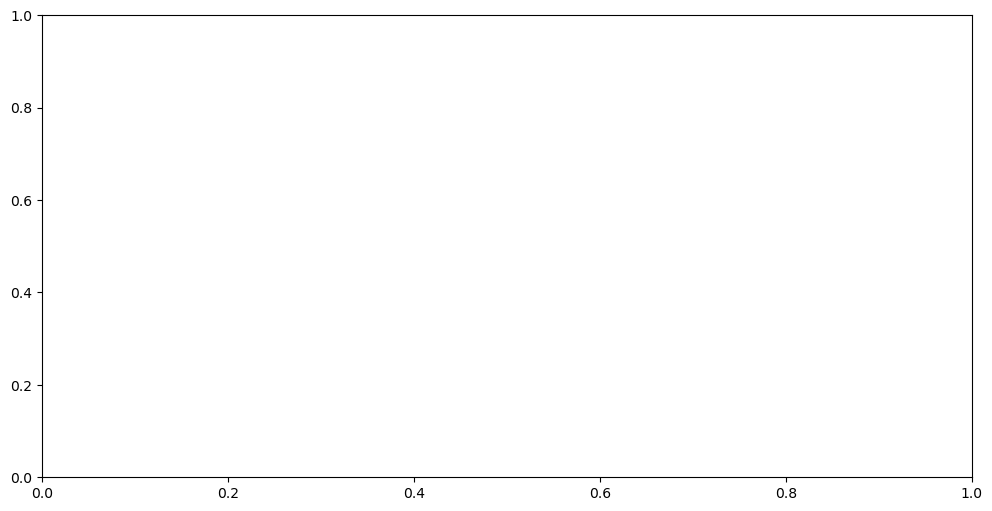

In [10]:

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_first_15['time'], df_first_15['AA03 (21.175) Middle Ave. (C)'], label='AA03 (21.175) Middle Ave. (C)', alpha=0.7)
ax1.plot(df_first_15['time'], df_first_15['AA03 (21.174) Middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', alpha=0.7)
ax1.plot(df_first_15['time'], df_first_15['AA03 (23.10) middle Ave. (C)'], label='AA03 (23.10) middle Ave. (C)', alpha=0.7)
#ax1.plot(df_first_15['time'], df_first_15['Uncoated middle Ave. (C)'], label='Uncoated middle Ave. (C)', color='#9d9d9c', alpha=0.7)

ax1.legend()
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (C)')
ax1.set_title('Three AA03 Comparisons')

ax2 = ax1.twinx()
ax2.plot(df_first_15['time'], df_first_15['Ambient Ave. (C)'], label='Ambient Ave. (C)', color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Ambient Temperature (C)')
#ax2.legend(loc='upper right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

In [81]:
diff_174 = df_first_15['Uncoated middle Ave. (C)'] - df_first_15['AA03 (21.174) Middle Ave. (C)']
diff_175 = df_first_15['Uncoated middle Ave. (C)'] - df_first_15['AA03 (21.175) Middle Ave. (C)']
diff_2310 = df_first_15['Uncoated middle Ave. (C)'] - df_first_15['AA03 (23.10) middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C):")
print(diff_174.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C):")
print(diff_175.describe())

print("\nDifference between Uncoated and AA03 (23.10) middle Ave. (C):")
print(diff_2310.describe())

Difference between Uncoated and AA03 (21.174) Middle Ave. (C):
count    896.000000
mean       5.290233
std        4.840903
min      -29.881000
25%        3.935750
50%        6.331000
75%        8.089000
max       12.912000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C):
count    896.000000
mean       4.212743
std        4.719413
min      -31.560000
25%        3.035500
50%        5.395500
75%        6.900000
max       10.269000
dtype: float64

Difference between Uncoated and AA03 (23.10) middle Ave. (C):
count    896.000000
mean       4.833048
std        5.102387
min      -29.884000
25%        3.208500
50%        5.438000
75%        8.572750
max       12.036000
dtype: float64


In [84]:
#t-test
from scipy import stats
#t-statistic gets the magnitude of difference between the means of 2 related samples
t_stat_174, p_val_174 = stats.ttest_rel(df_first_15['Uncoated middle Ave. (C)'], df_first_15['AA03 (21.174) Middle Ave. (C)'])
t_stat_175, p_val_175 = stats.ttest_rel(df_first_15['Uncoated middle Ave. (C)'], df_first_15['AA03 (21.175) Middle Ave. (C)'])
t_stat_2310, p_val_2310 = stats.ttest_rel(df_first_15['Uncoated middle Ave. (C)'], df_first_15['AA03 (23.10) middle Ave. (C)'])

print(f"21.174 t-stats: T-statistic = {t_stat_174:.4f}, p-value = {p_val_174:.4e}")
print(f"21.175 t-stats: T-statistic = {t_stat_175:.4f}, p-value = {p_val_175:.4e}")
print(f"23.10 t-stats: T-statistic = {t_stat_2310:.4f}, p-value = {p_val_2310:.4e}")

21.174 t-stats: T-statistic = 32.7116, p-value = 5.1692e-155
21.175 t-stats: T-statistic = 26.7197, p-value = 4.1296e-116
23.10 t-stats: T-statistic = 28.3532, p-value = 1.0673e-126


In [71]:
#get the top differences in diff_174
print(diff_174.sort_values(ascending=False).head(10))

0      18.067
1      15.896
379    12.912
380    12.844
2      12.756
660    12.427
383    12.387
382    12.268
381    12.263
384    11.995
dtype: float64


# 15 mins onwards at 450A

In [ ]:
#take from 900 onwards
df_after_15 = df_selected[df_selected['time'].between(df_selected['time'].iloc[901], df_selected['time'].iloc[2520])] #till 42 mins
print(df_selected['time'].iloc[1576]) #1545 to 1576
#theres an outlier with a value of -190, void that outlier
df_after_15 = df_after_15[(df_after_15['AA03 (23.10) middle Ave. (C)'] != -190.504) & (~df_after_15['time'].between(df_selected['time'].iloc[1545], df_selected['time'].iloc[1576]))]
print(len(df_after_15))


00:26:16
1588


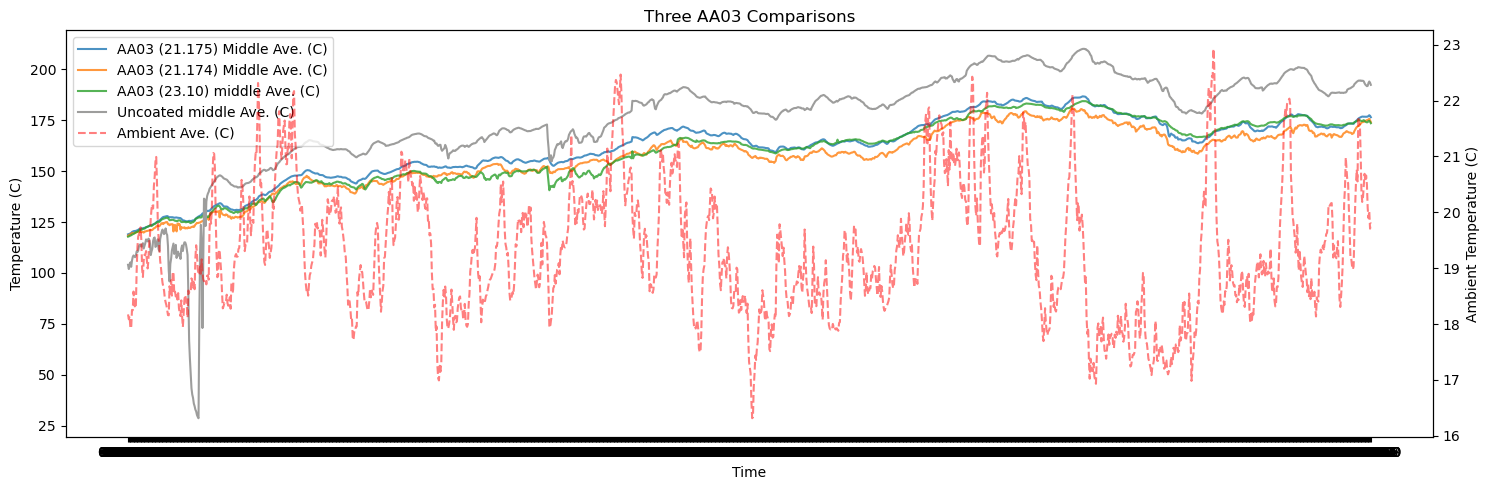

In [ ]:

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df_after_15['time'], df_after_15['AA03 (21.175) Middle Ave. (C)'], label='AA03 (21.175) Middle Ave. (C)', alpha=0.8)
ax1.plot(df_after_15['time'], df_after_15['AA03 (21.174) Middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', alpha=0.8)
ax1.plot(df_after_15['time'], df_after_15['AA03 (23.10) middle Ave. (C)'], label='AA03 (23.10) middle Ave. (C)', alpha=0.8)
#ax1.plot(df_after_15['time'], df_after_15['Uncoated middle Ave. (C)'], label='Uncoated middle Ave. (C)', color='#9d9d9c')

ax1.legend()
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (C)')
ax1.set_title('Three AA03 Comparisons')

ax2 = ax1.twinx()
ax2.plot(df_after_15['time'], df_after_15['Ambient Ave. (C)'], label='Ambient Ave. (C)', color='red', linestyle='--', alpha=0.5)
ax2.set_ylabel('Ambient Temperature (C)')
#ax2.legend(loc='upper right')

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [69]:
diff_174_2 = df_after_15['Uncoated middle Ave. (C)'] - df_after_15['AA03 (21.174) Middle Ave. (C)']
diff_175_2 = df_after_15['Uncoated middle Ave. (C)'] - df_after_15['AA03 (21.175) Middle Ave. (C)']
diff_2310_2 = df_after_15['Uncoated middle Ave. (C)'] - df_after_15['AA03 (23.10) middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C):")
print(diff_174_2.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C):")
print(diff_175_2.describe())

print("\nDifference between Uncoated and AA03 (23.10) middle Ave. (C):")
print(diff_2310_2.describe())

Difference between Uncoated and AA03 (21.174) Middle Ave. (C):
count    1588.000000
mean       18.844591
std        12.914515
min       -95.955000
25%        17.442500
50%        21.556000
75%        24.940250
max        32.266000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C):
count    1588.000000
mean       14.005336
std        12.183299
min       -99.048000
25%        13.174750
50%        16.444500
75%        19.250000
max        24.133000
dtype: float64

Difference between Uncoated and AA03 (23.10) middle Ave. (C):
count    1588.000000
mean       16.421244
std        12.345276
min       -98.533000
25%        16.436500
50%        18.726000
75%        20.977250
max        28.189000
dtype: float64


In [85]:
from scipy import stats

t_stat_174_2, p_val_174_2 = stats.ttest_rel(df_after_15['Uncoated middle Ave. (C)'], df_after_15['AA03 (21.174) Middle Ave. (C)'])
t_stat_175_2, p_val_175_2 = stats.ttest_rel(df_after_15['Uncoated middle Ave. (C)'], df_after_15['AA03 (21.175) Middle Ave. (C)'])
t_stat_2310_2, p_val_2310_2 = stats.ttest_rel(df_after_15['Uncoated middle Ave. (C)'], df_after_15['AA03 (23.10) middle Ave. (C)'])

print(f"21.174 t-stats: T-statistic = {t_stat_174_2:.4f}, p-value = {p_val_174_2:.4e}")
print(f"21.175 t-stats: T-statistic = {t_stat_175_2:.4f}, p-value = {p_val_175_2:.4e}")
print(f"23.10 t-stats: T-statistic = {t_stat_2310_2:.4f}, p-value = {p_val_2310_2:.4e}")

21.174 t-stats: T-statistic = 58.1479, p-value = 0.0000e+00
21.175 t-stats: T-statistic = 45.8093, p-value = 1.1671e-292
23.10 t-stats: T-statistic = 53.0067, p-value = 0.0000e+00


In [2]:
start = df_selected['time'].iloc[1545]
end = df_selected['time'].iloc[1576]
#16:18 to 16:32 (979-993)
start_2 = df_selected['time'].iloc[978]
end_2 = df_selected['time'].iloc[993]
df_selected.loc[df_selected['time'].between(start, end), 'AA03 (23.10) middle Ave. (C)'] = np.nan
df_selected.loc[df_selected['time'].between(start_2, end_2), 'Uncoated middle Ave. (C)'] = np.nan
df_selected = df_selected[df_selected['time'].between(df_selected['time'].iloc[5], df_selected['time'].iloc[2520])]
df_cleaned = df_selected[(df_selected['AA03 (23.10) middle Ave. (C)'] != -190.504) & (~df_selected['time'].between(df_selected['time'].iloc[1545], df_selected['time'].iloc[1576])) 
                         & (~df_selected['time'].between(df_selected['time'].iloc[978], df_selected['time'].iloc[992]))]

print(len(df_cleaned))
df_cleaned['time'] = pd.to_datetime(df_cleaned['time'], format="%H:%M:%S")

print(df_cleaned['time'])

2469
5      1900-01-01 00:00:05
6      1900-01-01 00:00:06
7      1900-01-01 00:00:07
8      1900-01-01 00:00:08
9      1900-01-01 00:00:09
               ...        
2516   1900-01-01 00:41:56
2517   1900-01-01 00:41:57
2518   1900-01-01 00:41:58
2519   1900-01-01 00:41:59
2520   1900-01-01 00:42:00
Name: time, Length: 2469, dtype: datetime64[ns]


C:\Users\ErnestKhong\AppData\Local\Temp\ipykernel_52988\3546022516.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['time'] = pd.to_datetime(df_cleaned['time'], format="%H:%M:%S")


In [88]:
#print(df row 1545)
print(df_cleaned.loc[993])

time                                 1900-01-01 00:16:33
AA03 (21.175) ConnectorR Ave. (C)                 95.956
AA03 (21.175) Middle Ave. (C)                    128.126
AA03 (21.175) ConnectorL Ave. (C)                 90.021
AA03 (21.174) ConnectorR Ave. (C)                 93.966
AA03 (21.174) Middle Ave. (C)                    124.689
AA03 (21.174) ConnectorL Ave. (C)                 89.956
Uncoated ConnectorR Ave. (C)                      90.265
Uncoated middle Ave. (C)                             NaN
Uncoated ConnectorL Ave. (C)                      85.651
AA03 (23.10) ConnectorR Ave. (C)                  89.464
AA03 (23.10) middle Ave. (C)                     127.266
AA03 (23.10) ConnectorL Ave. (C)                  79.519
Ambient Ave. (C)                                  19.026
Name: 993, dtype: object


In [84]:
print(len(df_cleaned))

2484


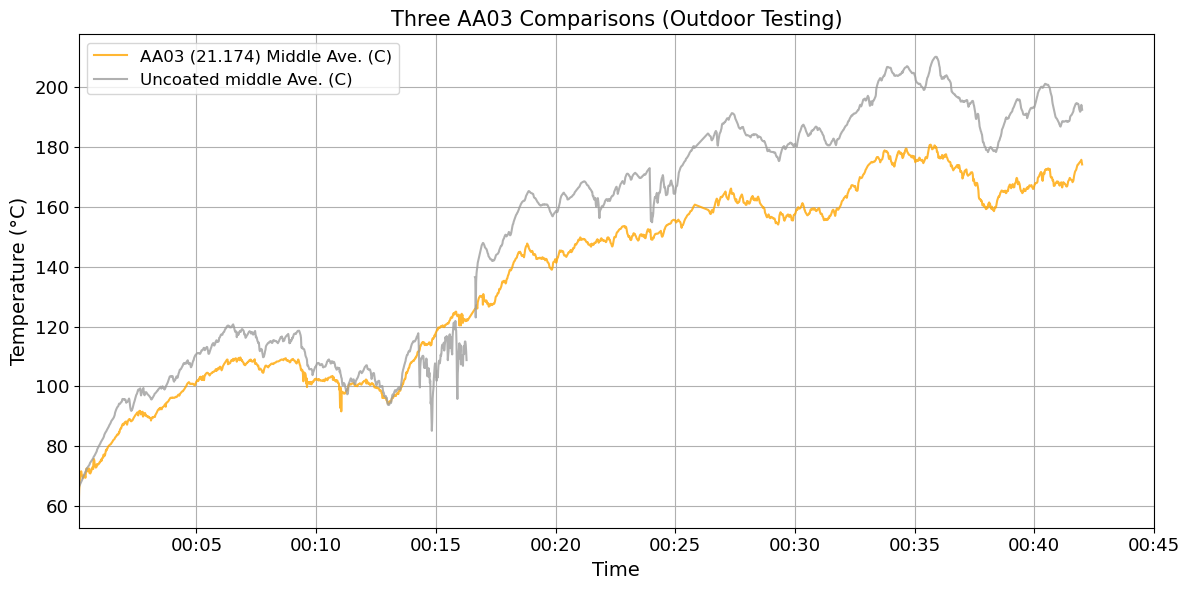

In [5]:
import matplotlib.dates as mdates

fig = plt.figure(figsize=(12, 6))
#plt.plot(df_cleaned['time'], df_cleaned['AA03 (21.175) Middle Ave. (C)'], label='AA03 (21.175) Middle Ave. (C)', alpha=0.8)
plt.plot(df_cleaned['time'], df_cleaned['AA03 (21.174) Middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', alpha=0.8, color='orange')
#plt.plot(df_cleaned['time'], df_cleaned['AA03 (23.10) middle Ave. (C)'], label='AA03 (23.10) middle Ave. (C)', alpha=0.8)
plt.plot(df_cleaned['time'], df_cleaned['Uncoated middle Ave. (C)'], label='Uncoated middle Ave. (C)', color='#9d9d9c', alpha=0.8)
plt.legend(fontsize=12)

plt.xlabel('Time', fontsize=14)
plt.xticks(size=13)
plt.yticks(size=13)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.title('Three AA03 Comparisons (Outdoor Testing)', fontsize=15)
plt.grid(True, 'both') #make a double grid with major and minor gridlines

ax = plt.gca() #get current axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

max = df_cleaned['time'].max()+pd.Timedelta(minutes=3)
ax.set_xlim(df_cleaned['time'].min(), max) 
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5)) #set major ticks every 5 minutes
#set bins every 5 minutes with 0,5,10,15,20,25,30,35,40,45,50,55

plt.tight_layout()
plt.show()

# INDOOR TEST

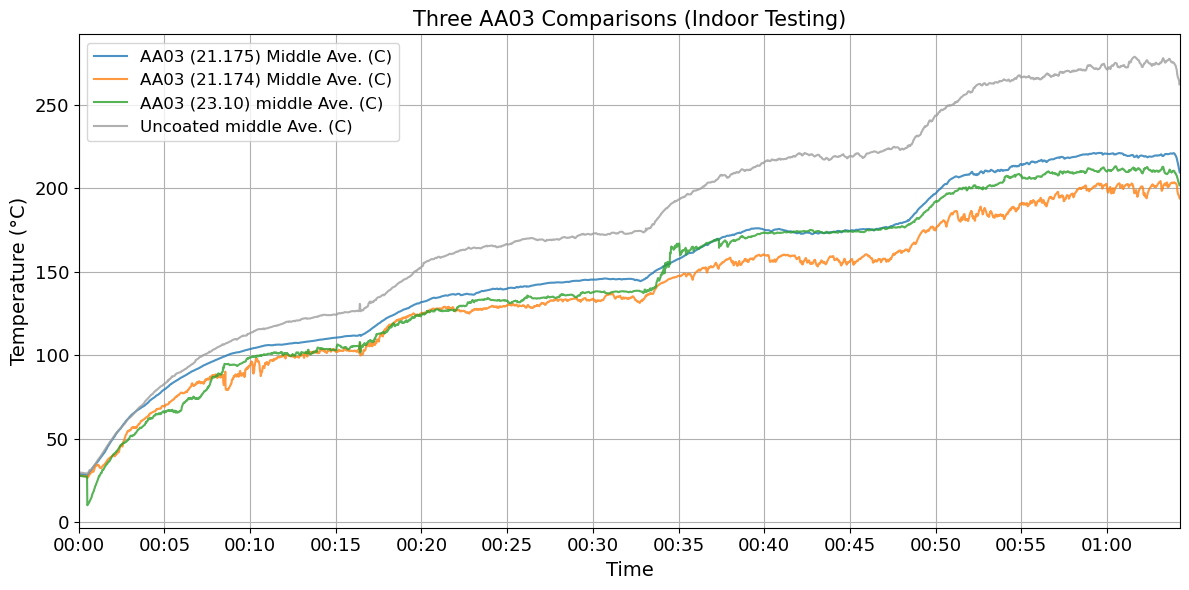

In [115]:
df = pd.read_excel("Dta indoor testing on 27042026.xlsx")

import matplotlib.dates as mdates

df['time'] = pd.to_datetime(df['time'], format="%H:%M:%S")

fig = plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['Coated 21.175 middle Ave. (C)'], label='AA03 (21.175) Middle Ave. (C)', alpha=0.8)
plt.plot(df['time'], df['Coated 21.174.middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', alpha=0.8)
plt.plot(df['time'], df['Coted 23.10 middle Ave. (C)'], label='AA03 (23.10) middle Ave. (C)', alpha=0.8)
plt.plot(df['time'], df['Uncoated middle  Ave. (C)'], label='Uncoated middle Ave. (C)', color='#9d9d9c', alpha=0.8)
plt.legend(fontsize=12)

plt.xlabel('Time', fontsize=14)
plt.xticks(size=13)
plt.yticks(size=13)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.title('Three AA03 Comparisons (Indoor Testing)', fontsize=15)
plt.grid(True, 'both') #make a double grid with major and minor gridlines

ax = plt.gca() #get current axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

max = df['time'].max()
ax.set_xlim(df['time'].min(), max) 
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5)) #set major ticks every 5 minutes
#set bins every 5 minutes with 0,5,10,15,20,25,30,35,40,45,50,55

plt.tight_layout()
plt.show()

In [106]:
print(df.loc[901])

time                             1900-01-01 00:15:01
Uncoated middle  Last (C)                    124.175
Uncoated middle  Ave. (C)                    124.175
Uncoated middle  Min. (C)                    124.175
Uncoated middle  Max. (C)                    124.175
Coted 23.10 middle Last (C)                  103.041
Coted 23.10 middle Ave. (C)                  103.041
Coted 23.10 middle Min. (C)                  103.041
Coted 23.10 middle Max. (C)                  103.041
Coated 21.175 middle Last (C)                 110.47
Coated 21.175 middle Ave. (C)                 110.47
Coated 21.175 middle Min. (C)                 110.47
Coated 21.175 middle Max. (C)                 110.47
Coated 21.174.middle Last (C)                102.003
Coated 21.174.middle Ave. (C)                102.003
Coated 21.174.middle Min. (C)                102.003
Coated 21.174.middle Max. (C)                102.003
Name: 901, dtype: object


In [107]:
df_300A = df[df['time'].between(df['time'].iloc[0], df['time'].iloc[900])]
df_350A = df[df['time'].between(df['time'].iloc[901], df['time'].iloc[1800])]
df_400A = df[df['time'].between(df['time'].iloc[1801], df['time'].iloc[2700])]
df_450A = df[df['time'].between(df['time'].iloc[2701], df['time'].iloc[3854])]

## 300A

In [110]:
from scipy import stats
diff_174_300A = df_300A['Uncoated middle  Ave. (C)'] - df_300A['Coated 21.174.middle Ave. (C)']
diff_175_300A = df_300A['Uncoated middle  Ave. (C)'] - df_300A['Coated 21.175 middle Ave. (C)']
diff_2310_300A = df_300A['Uncoated middle  Ave. (C)'] - df_300A['Coted 23.10 middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 300A:")
print(diff_174_300A.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C) at 300A:")
print(diff_175_300A.describe())

print("\nDifference between Uncoated and AA03 (23.10) Middle Ave. (C) at 300A:")
print(diff_2310_300A.describe())

t_stat_174_300A, p_val_174_300A = stats.ttest_rel(df_300A['Uncoated middle  Ave. (C)'], df_300A['Coated 21.174.middle Ave. (C)'])
t_stat_175_300A, p_val_175_300A = stats.ttest_rel(df_300A['Uncoated middle  Ave. (C)'], df_300A['Coated 21.175 middle Ave. (C)'])
t_stat_2310_300A, p_val_2310_300A = stats.ttest_rel(df_300A['Uncoated middle  Ave. (C)'], df_300A['Coted 23.10 middle Ave. (C)'])

print(f"300A - 21.174 t-stats: T-statistic = {t_stat_174_300A:.4f}, p-value = {p_val_174_300A:.4e}")
print(f"300A - 21.175 t-stats: T-statistic = {t_stat_175_300A:.4f}, p-value = {p_val_175_300A:.4e}")
print(f"300A - 23.10 t-stats: T-statistic = {t_stat_2310_300A:.4f}, p-value = {p_val_2310_300A:.4e}")

Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 300A:
count    901.000000
mean      15.464978
std        6.402266
min        1.355000
25%       10.880000
50%       15.554000
75%       20.889000
max       28.407000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C) at 300A:
count    901.000000
mean       6.613160
std        4.989278
min       -0.788000
25%        1.429000
50%        6.305000
75%       10.924000
max       14.693000
dtype: float64

Difference between Uncoated and AA03 (23.10) Middle Ave. (C) at 300A:
count    901.000000
mean      16.223125
std        4.514512
min        1.943000
25%       13.171000
50%       16.075000
75%       20.071000
max       24.328000
dtype: float64
300A - 21.174 t-stats: T-statistic = 72.5067, p-value = 0.0000e+00
300A - 21.175 t-stats: T-statistic = 39.7863, p-value = 1.5691e-200
300A - 23.10 t-stats: T-statistic = 107.8664, p-value = 0.0000e+00


In [111]:
from scipy import stats
diff_174_350A = df_350A['Uncoated middle  Ave. (C)'] - df_350A['Coated 21.174.middle Ave. (C)']
diff_175_350A = df_350A['Uncoated middle  Ave. (C)'] - df_350A['Coated 21.175 middle Ave. (C)']
diff_2310_350A = df_350A['Uncoated middle  Ave. (C)'] - df_350A['Coted 23.10 middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 350A:")
print(diff_174_350A.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C) at 350A:")
print(diff_175_350A.describe())

print("\nDifference between Uncoated and AA03 (23.10) Middle Ave. (C) at 350A:")
print(diff_2310_350A.describe())

t_stat_174_350A, p_val_174_350A = stats.ttest_rel(df_350A['Uncoated middle  Ave. (C)'], df_350A['Coated 21.174.middle Ave. (C)'])
t_stat_175_350A, p_val_175_350A = stats.ttest_rel(df_350A['Uncoated middle  Ave. (C)'], df_350A['Coated 21.175 middle Ave. (C)'])
t_stat_2310_350A, p_val_2310_350A = stats.ttest_rel(df_350A['Uncoated middle  Ave. (C)'], df_350A['Coted 23.10 middle Ave. (C)'])

print(f"350A - 21.174 t-stats: T-statistic = {t_stat_174_350A:.4f}, p-value = {p_val_174_350A:.4e}")
print(f"350A - 21.175 t-stats: T-statistic = {t_stat_175_350A:.4f}, p-value = {p_val_175_350A:.4e}")
print(f"350A - 23.10 t-stats: T-statistic = {t_stat_2310_350A:.4f}, p-value = {p_val_2310_350A:.4e}")

Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 350A:
count    900.000000
mean      32.117318
std        6.571730
min       20.570000
25%       24.920000
50%       36.022000
75%       37.364250
max       41.892000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C) at 350A:
count    900.000000
mean      22.835827
std        4.941491
min       13.705000
25%       17.522000
50%       25.445000
75%       26.749000
max       28.820000
dtype: float64

Difference between Uncoated and AA03 (23.10) Middle Ave. (C) at 350A:
count    900.000000
mean      30.109243
std        5.333539
min       18.447000
25%       24.426500
50%       32.266000
75%       34.581250
max       37.087000
dtype: float64
350A - 21.174 t-stats: T-statistic = 146.6158, p-value = 0.0000e+00
350A - 21.175 t-stats: T-statistic = 138.6373, p-value = 0.0000e+00
350A - 23.10 t-stats: T-statistic = 169.3580, p-value = 0.0000e+00


In [112]:
from scipy import stats
diff_174_400A = df_400A['Uncoated middle  Ave. (C)'] - df_400A['Coated 21.174.middle Ave. (C)']
diff_175_400A = df_400A['Uncoated middle  Ave. (C)'] - df_400A['Coated 21.175 middle Ave. (C)']
diff_2310_400A = df_400A['Uncoated middle  Ave. (C)'] - df_400A['Coted 23.10 middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 400A:")
print(diff_174_400A.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C) at 400A:")
print(diff_175_400A.describe())

print("\nDifference between Uncoated and AA03 (23.10) Middle Ave. (C) at 400A:")
print(diff_2310_400A.describe())

t_stat_174_400A, p_val_174_400A = stats.ttest_rel(df_400A['Uncoated middle  Ave. (C)'], df_400A['Coated 21.174.middle Ave. (C)'])
t_stat_175_400A, p_val_175_400A = stats.ttest_rel(df_400A['Uncoated middle  Ave. (C)'], df_400A['Coated 21.175 middle Ave. (C)'])
t_stat_2310_400A, p_val_2310_400A = stats.ttest_rel(df_400A['Uncoated middle  Ave. (C)'], df_400A['Coted 23.10 middle Ave. (C)'])

print(f"400A - 21.174 t-stats: T-statistic = {t_stat_174_400A:.4f}, p-value = {p_val_174_400A:.4e}")
print(f"400A - 21.175 t-stats: T-statistic = {t_stat_175_400A:.4f}, p-value = {p_val_175_400A:.4e}")
print(f"400A - 23.10 t-stats: T-statistic = {t_stat_2310_400A:.4f}, p-value = {p_val_2310_400A:.4e}")

Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 400A:
count    900.000000
mean      51.046807
std        8.999387
min       35.863000
25%       41.798500
50%       51.681500
75%       59.069000
max       66.852000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C) at 400A:
count    900.000000
mean      36.785906
std        6.546094
min       26.063000
25%       30.534500
50%       36.066000
75%       43.017000
max       47.958000
dtype: float64

Difference between Uncoated and AA03 (23.10) Middle Ave. (C) at 400A:
count    900.000000
mean      39.076572
std        4.945592
min       25.670000
25%       35.227000
50%       39.546500
75%       43.958500
max       47.022000
dtype: float64
400A - 21.174 t-stats: T-statistic = 170.1676, p-value = 0.0000e+00
400A - 21.175 t-stats: T-statistic = 168.5856, p-value = 0.0000e+00
400A - 23.10 t-stats: T-statistic = 237.0388, p-value = 0.0000e+00


In [113]:
from scipy import stats
diff_174_450A = df_450A['Uncoated middle  Ave. (C)'] - df_450A['Coated 21.174.middle Ave. (C)']
diff_175_450A = df_450A['Uncoated middle  Ave. (C)'] - df_450A['Coated 21.175 middle Ave. (C)']
diff_2310_450A = df_450A['Uncoated middle  Ave. (C)'] - df_450A['Coted 23.10 middle Ave. (C)']

print("Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 450A:")
print(diff_174_450A.describe())

print("\nDifference between Uncoated and AA03 (21.175) Middle Ave. (C) at 450A:")
print(diff_175_450A.describe())

print("\nDifference between Uncoated and AA03 (23.10) Middle Ave. (C) at 450A:")
print(diff_2310_450A.describe())

t_stat_174_450A, p_val_174_450A = stats.ttest_rel(df_450A['Uncoated middle  Ave. (C)'], df_450A['Coated 21.174.middle Ave. (C)'])
t_stat_175_450A, p_val_175_450A = stats.ttest_rel(df_450A['Uncoated middle  Ave. (C)'], df_450A['Coated 21.175 middle Ave. (C)'])
t_stat_2310_450A, p_val_2310_450A = stats.ttest_rel(df_450A['Uncoated middle  Ave. (C)'], df_450A['Coted 23.10 middle Ave. (C)'])

print(f"450A - 21.174 t-stats: T-statistic = {t_stat_174_450A:.4f}, p-value = {p_val_174_450A:.4e}")
print(f"450A - 21.175 t-stats: T-statistic = {t_stat_175_450A:.4f}, p-value = {p_val_175_450A:.4e}")
print(f"450A - 23.10 t-stats: T-statistic = {t_stat_2310_450A:.4f}, p-value = {p_val_2310_450A:.4e}")

Difference between Uncoated and AA03 (21.174) Middle Ave. (C) at 450A:
count    1154.000000
mean       71.094665
std         5.887290
min        58.946000
25%        65.727250
50%        72.221000
75%        75.470750
max        83.657000
dtype: float64

Difference between Uncoated and AA03 (21.175) Middle Ave. (C) at 450A:
count    1154.000000
mean       50.108425
std         3.992233
min        42.560000
25%        46.085500
50%        50.954500
75%        52.915000
max        60.088000
dtype: float64

Difference between Uncoated and AA03 (23.10) Middle Ave. (C) at 450A:
count    1154.000000
mean       57.040827
std         6.463888
min        44.295000
25%        51.466250
50%        59.462000
75%        61.662500
max        68.113000
dtype: float64
450A - 21.174 t-stats: T-statistic = 410.2272, p-value = 0.0000e+00
450A - 21.175 t-stats: T-statistic = 426.3809, p-value = 0.0000e+00
450A - 23.10 t-stats: T-statistic = 299.7747, p-value = 0.0000e+00


In [ ]:
import os
import sys

from flexlogger.automation import Application

def main(project_path):
    with Application.launch() as app:
        project = app.open_project(project_path)
        logging_specification = project.open_logging_specification_document()
        log_file_base_path = logging_specification.get_log_file_base_path()
        log_file_name = logging_specification.get_log_file_name()
        print("Log file base path: " + log_file_base_path)
        print("Log file name: " + log_file_name)
        print("Press Enter to close the project...")
        input()
        project.close()
    return 0


if __name__ == "__main__":
    argv = sys.argv
    if len(argv) < 2:
        print("Usage: %s <path of project to open>" % os.path.basename(__file__))
        sys.exit()
    project_path_arg = argv[1]
    sys.exit(main(project_path_arg))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\LogFile_2026-04-30-10-55-15.csv', encoding='utf-8')
df

,21.174,21.175,23.1,ambient,Uncoated
0,33.642708,35.929272,35.101327,16.536737,32.958429
1,33.747830,36.105858,35.203674,16.507208,33.099669
2,33.836117,36.254930,35.297070,16.459541,33.192794
3,33.908798,36.358744,35.408023,16.379859,33.250064
4,34.003295,36.424190,35.505364,16.335860,33.297948
...,...,...,...,...,...
1124,53.529996,62.080242,59.967720,18.620960,59.393186
1125,53.269848,61.950913,59.882475,18.652571,59.309345
1126,52.939672,61.812327,59.849832,18.665084,59.220706
1127,52.628333,61.650966,59.797570,18.700319,59.074592


In [25]:
#remove outliers
df = pd.read_excel("Dta indoor testing on 27042026.xlsx")

def remove_outliers_rolling(df, col, window, threshold):
    rolling_median = df[col].rolling(window, center=True, min_periods=1).median()
    diff = abs(df[col] - rolling_median)

    return df[diff<threshold]
#threshold is the value that determines hwo far the value is from the centered rolling median
cleaned = remove_outliers_rolling(df, 'Coated 21.174.middle Ave. (C)', window=20, threshold=5)

removed = df.loc[~df.index.isin(cleaned.index)]
print(len(df), len(cleaned), len(removed))
print(removed[['Coated 21.174.middle Ave. (C)']])

#Option A; Moving avg smoothing
def smoothen(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()
df['21.174_v2'] = smoothen(df['Coated 21.174.middle Ave. (C)'], window_size=20)
#df['21.174_v3'] = df['21.174'].diff()

#Option B: Exponential Moving Average
#alpha is the smoothing facotr, a smaller alpha smoothen results more because it reacts slower to changes
#span is the window size, a smaller span reacts more quickly to changes, a larger span reacts slower to changes
def smoothen_ema(df, alpha, adjust=False):
    return df.ewm(alpha=alpha, adjust=adjust).mean()
df['21.174_v3'] = smoothen_ema(df['Coated 21.174.middle Ave. (C)'], 0.3) 

print(df[['time', 'Coated 21.174.middle Ave. (C)', '21.174_v2', '21.174_v3']].head(20))
print(len(df))

3857 3849 8
      Coated 21.174.middle Ave. (C)
513                          90.145
610                          89.246
611                          89.511
612                          89.035
614                          90.365
984                         107.318
985                         107.059
3856                            NaN
        time  Coated 21.174.middle Ave. (C)  21.174_v2  21.174_v3
0   00:00:00                         27.942  27.942000  27.942000
1   00:00:01                         27.913  27.927500  27.933300
2   00:00:02                         27.876  27.910333  27.916110
3   00:00:03                         27.848  27.894750  27.895677
4   00:00:04                         27.835  27.882800  27.877474
5   00:00:05                         27.828  27.873667  27.862632
6   00:00:06                         27.828  27.867143  27.852242
7   00:00:07                         27.809  27.859875  27.839270
8   00:00:08                         27.813  27.854667  27.831389
9   

In [26]:
print(df)

      Index      time  Uncoated middle  Last (C)  Uncoated middle  Ave. (C)  \
0         0  00:00:00                     29.858                     29.858   
1         1  00:00:01                     29.825                     29.825   
2         2  00:00:02                     29.799                     29.799   
3         3  00:00:03                     29.770                     29.770   
4         4  00:00:04                     29.759                     29.759   
...     ...       ...                        ...                        ...   
3852   3852  01:04:12                    264.887                    264.887   
3853   3853  01:04:13                    264.171                    264.171   
3854   3854  01:04:14                    262.191                    262.191   
3855   3855  01:04:15                        NaN                        NaN   
3856   3856  01:04:16                        NaN                        NaN   

      Uncoated middle  Min. (C)  Uncoated middle  M

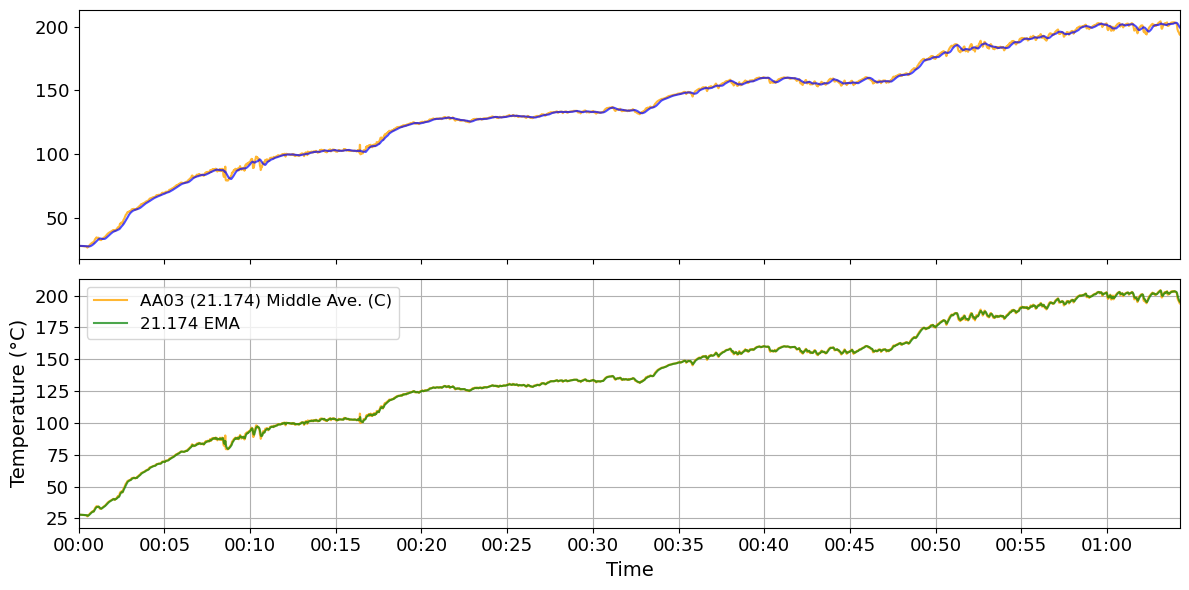

In [36]:
#plt.plot(df['time'], df['Coated 21.175 middle Ave. (C)'], label='AA03 (21.175) Middle Ave. (C)', alpha=0.8)
#plt.plot(df['time'], df['Coted 23.10 middle Ave. (C)'], label='AA03 (23.10) middle Ave. (C)', alpha=0.8)



import matplotlib.dates as mdates

df['time'] = pd.to_datetime(df['time'], format="%H:%M:%S")

fig, ax = plt.subplots(2,1, figsize=(12, 6), sharex=True)
#amke 2 plots, one with the original data and one with the smoothed data, with the same x-axis
ax[0].plot(df['time'], df['Coated 21.174.middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', color='orange', alpha=0.8)
ax[0].plot(df['time'], df['21.174_v2'], label='21.174 Moving Avg', color='blue', alpha=0.7)

ax[1].plot(df['time'], df['Coated 21.174.middle Ave. (C)'], label='AA03 (21.174) Middle Ave. (C)', color='orange', alpha=0.8)
ax[1].plot(df['time'], df['21.174_v3'], label='21.174 EMA', color='green', alpha=0.7)
plt.legend(fontsize=12)

plt.xlabel('Time', fontsize=14)
plt.xticks(size=13)
plt.yticks(size=13)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.grid(True, 'both') #make a double grid with major and minor gridlines

#adjust size of ax[1] y ticks
ax[0].tick_params(axis='y', labelsize=13)

ax = plt.gca() #get current axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

max = df['time'].max()
ax.set_xlim(df['time'].min(), max) 
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5)) #set major ticks every 5 minutes
#set bins every 5 minutes with 0,5,10,15,20,25,30,35,40,45,50,55

plt.tight_layout()
plt.show()

In [10]:


# df['time'] = df.index
# plt.plot(df['time'], df['21.174'], color='orange', label='AA03 (21.174)', alpha=0.7)
# #plt.plot(df['time'], df['21.174_v2'], color='red', label='AA03 (21.174) Smoothed', alpha=0.6)
# plt.plot(df['time'], df['21.174_v3'], color='blue', label='AA03 (21.174) EMA Smoothed', alpha=0.6)
# #plt.plot(df['time'], df['21.175'], color='blue', label='AA03 (21.175)')
# #plt.plot(df['time'], df['23.1'], color='green', label='AA03 (23.1)')
# plt.plot(df['time'], df['Uncoated'], color='#9d9d9c', label='Uncoated')

# plt.xlabel('Time')
# plt.ylabel('Temperature (C)')
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.legend()

# plt.tight_layout()
# plt.show()

In [37]:
import os
folder_path = "G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs"
os.listdir(folder_path)

['log_10_30-30-04.csv', 'Ignore.CSV']

In [16]:
from datetime import timedelta

def remove_outliers_rolling(df, col, window, threshold):
    #2 step process, 1st is applying rolling median to remove outliers, then SMA for smoothing
    rolling_median = df[col].rolling(window, center=True, min_periods=1).median()
    diff = abs(df[col] - rolling_median)

    removed = df.loc[diff>=threshold]
    print(f"Removed {len(removed)} outliers from column {col} using rolling median with window {window} and threshold {threshold}.")

    return df[diff<threshold]

def smoothen(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()

def add_timestamp_from_index(df):
    df = df.copy()
    #tiem format is "55:50.5"

    df['Time'] = pd.to_datetime(df['Time'], format="%M:%S.%f")
    
    df['timestamp'] = df['Time'].dt.strftime("%H:%M")#reformat time to just %H:%M
    return df

In [5]:
import pandas as pd
df = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test_0505\log-05052026-14-55.csv.csv')
df

,Time,21.174-1,21.174-2,21.174-3,21.174-4,21.175-1,21.175-2,21.175-3,21.175-4,23.10-1,23.10-2,23.10-3,23.10-4,Ambient,Uncoated -2,Uncoated -4,Uncoted -1,Uncotoad -3
0,55:50.5,19.684209,19.642818,19.606742,19.535969,19.551004,19.467499,19.404572,19.354363,19.340711,19.279849,19.224072,19.146991,19.347200,19.752427,19.648378,19.842121,19.698093
1,55:51.5,19.677124,19.637351,19.612838,19.539753,19.553400,19.469433,19.399565,19.351207,19.342414,19.284330,19.230867,19.150778,19.336439,19.742831,19.643174,19.839693,19.705606
2,55:52.5,19.684927,19.638217,19.612085,19.539463,19.549640,19.464285,19.407141,19.348140,19.337264,19.281956,19.223402,19.144932,19.338054,19.749531,19.645019,19.833909,19.699590
3,55:53.5,19.678340,19.645273,19.613129,19.538194,19.564792,19.464866,19.405640,19.348258,19.332523,19.283926,19.223983,19.144819,19.339058,19.747759,19.634922,19.838610,19.704755
4,55:54.5,19.684144,19.646684,19.609221,19.539605,19.564353,19.474374,19.397798,19.351522,19.353604,19.278396,19.222156,19.140676,19.335713,19.754128,19.644761,19.830646,19.700488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,55:46.5,123.796183,132.906468,114.485070,102.009580,113.768498,124.048725,124.289459,118.586357,115.525248,100.029991,125.024795,118.553240,20.360764,133.056821,118.107098,123.362229,128.733527
3597,55:47.5,123.770462,132.939152,114.504592,102.019547,113.756639,124.022437,124.277011,118.615058,115.525481,99.998761,125.043639,118.554634,20.372598,133.024606,118.112380,123.365548,128.729376
3598,55:48.5,123.745023,132.968508,114.507254,102.031393,113.749553,124.012956,124.287128,118.629905,115.510048,99.961847,125.055088,118.554182,20.371419,133.017374,118.147629,123.364950,128.752645
3599,55:49.5,123.741620,132.967237,114.498546,102.038601,113.774382,124.022046,124.345196,118.642744,115.505244,99.948562,125.049965,118.553078,20.377834,133.013538,118.195065,123.385104,128.746686


In [15]:
remove_outliers_rolling(df, col='Uncoated -2', window=20, threshold=5)
smoothen(df[['21.174-1', 'Uncoated -2']], window_size=20)

Removed 0 outliers from column Uncoated -2 using rolling median with window 20 and threshold 5.


,21.174-1,Uncoated -2
0,19.684209,19.752427
1,19.680667,19.747629
2,19.682087,19.748263
3,19.681150,19.748137
4,19.681749,19.749335
...,...,...
3596,123.385285,133.066525
3597,123.416616,133.062851
3598,123.447094,133.059340
3599,123.476187,133.056604


In [17]:
df = add_timestamp_from_index(df)
df

,Time,21.174-1,21.174-2,21.174-3,21.174-4,21.175-1,21.175-2,21.175-3,21.175-4,23.10-1,23.10-2,23.10-3,23.10-4,Ambient,Uncoated -2,Uncoated -4,Uncoted -1,Uncotoad -3,timestamp
0,1900-01-01 00:55:50.500,19.684209,19.642818,19.606742,19.535969,19.551004,19.467499,19.404572,19.354363,19.340711,19.279849,19.224072,19.146991,19.347200,19.752427,19.648378,19.842121,19.698093,00:55
1,1900-01-01 00:55:51.500,19.677124,19.637351,19.612838,19.539753,19.553400,19.469433,19.399565,19.351207,19.342414,19.284330,19.230867,19.150778,19.336439,19.742831,19.643174,19.839693,19.705606,00:55
2,1900-01-01 00:55:52.500,19.684927,19.638217,19.612085,19.539463,19.549640,19.464285,19.407141,19.348140,19.337264,19.281956,19.223402,19.144932,19.338054,19.749531,19.645019,19.833909,19.699590,00:55
3,1900-01-01 00:55:53.500,19.678340,19.645273,19.613129,19.538194,19.564792,19.464866,19.405640,19.348258,19.332523,19.283926,19.223983,19.144819,19.339058,19.747759,19.634922,19.838610,19.704755,00:55
4,1900-01-01 00:55:54.500,19.684144,19.646684,19.609221,19.539605,19.564353,19.474374,19.397798,19.351522,19.353604,19.278396,19.222156,19.140676,19.335713,19.754128,19.644761,19.830646,19.700488,00:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,1900-01-01 00:55:46.500,123.796183,132.906468,114.485070,102.009580,113.768498,124.048725,124.289459,118.586357,115.525248,100.029991,125.024795,118.553240,20.360764,133.056821,118.107098,123.362229,128.733527,00:55
3597,1900-01-01 00:55:47.500,123.770462,132.939152,114.504592,102.019547,113.756639,124.022437,124.277011,118.615058,115.525481,99.998761,125.043639,118.554634,20.372598,133.024606,118.112380,123.365548,128.729376,00:55
3598,1900-01-01 00:55:48.500,123.745023,132.968508,114.507254,102.031393,113.749553,124.012956,124.287128,118.629905,115.510048,99.961847,125.055088,118.554182,20.371419,133.017374,118.147629,123.364950,128.752645,00:55
3599,1900-01-01 00:55:49.500,123.741620,132.967237,114.498546,102.038601,113.774382,124.022046,124.345196,118.642744,115.505244,99.948562,125.049965,118.553078,20.377834,133.013538,118.195065,123.385104,128.746686,00:55


In [3]:
df = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test_0705\compiled_logs.csv')
#print(df)

def process_spikes(df, col, window = 60, threshold=5):
    df = df.copy()

    change_col = f"{col}_window_change"
    event_col = col
    start_col = f"{col}_start"

    df[change_col] = df[col] - df[col].shift(window)
    df[event_col] = (df[change_col]>threshold).fillna(False).astype(bool)
    previous_event = df[event_col].shift(1, fill_value=False).astype(bool)

    df[start_col] = df[event_col] & ~previous_event
    
    return df

spike_indices = process_spikes(df, col='AA03-1-2_flex', window=90, threshold=5)
print(spike_indices)
print(len(spike_indices[spike_indices['AA03-1-2_flex_start'] == True]))
#get me the indices where AA03-1-2_flex_start is True
spike_start_indices = spike_indices[spike_indices['AA03-1-2_flex_start'] == True].index
print(spike_start_indices)

     Time_flex  AA03-1-1_flex  AA03-1-2_flex  AA03-1-3_flex  AA03-1-4_flex  \
0      33:38.1      18.680539          False      18.576946      18.507408   
1      33:39.1      18.678375          False      18.586139      18.507330   
2      33:40.1      18.666922          False      18.570743      18.501899   
3      33:41.1      18.666623          False      18.578325      18.507860   
4      33:42.1      18.676524          False      18.585446      18.508723   
...        ...            ...            ...            ...            ...   
3779   39:03.1     160.715958          False     152.434034     151.491090   
3780   39:04.1     160.740416          False     152.477060     151.550654   
3781   39:05.1     160.781544          False     152.505103     151.632445   
3782   39:06.1     160.796246          False     152.511815     151.690284   
3783   39:07.1     160.766028          False     152.510890     151.743252   

      Unnamed: 5  AA03-2-1_flex  AA03-2-2_flex  AA03-2-3_flex  

In [18]:
print(len(spike_indices))

544


# Thermocouple Processing

In [11]:
#folder_path = "G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test_0705"
folder_path = "G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805"
sum = 0
for file in os.listdir(folder_path):
    if file.endswith(".csv.csv"):
        file_path = os.path.join(folder_path, file)
        print(f"Processing file: {file_path}")
        df = pd.read_csv(file_path)
        print(len(df))
        sum += len(df)
        #concat all files
        df_compiled = pd.concat([df_compiled, df], ignore_index=True) if 'df_compiled' in locals() else df
print(f"Total rows across all files: {sum}")
print(len(df_compiled))
print(df_compiled)
#for all column names in df_compiled, add a _flex suffix
df_compiled.columns = [col + '_flex' for col in df_compiled.columns]
print(df_compiled.columns)

Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-10-57.csv.csv
302
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-02.csv.csv
300
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-07.csv.csv
300
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-12.csv.csv
300
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-17.csv.csv
300
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-22.csv.csv
299
Processing file: G:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test-0805\LogFile_20260508-11-27.csv.csv
192
Total 

In [12]:
df_compiled.to_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test-0805\compiled_logs.csv', index=False)

In [13]:
df = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test-0805\compiled_logs.csv')
df_pico = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test-0805\Picolog\\test0805average.csv')

#i want to compared each of the columns in the df, example compare col 1 of df and col 1 of df b, then col 2 of df a and col 2 of df b, and so on, and get the correlation coefficient for each pair of columns, and print the results in a readable format
correlation_results = {}
avg_diffs = {}
#each col i want to compare are the in the same column alphabet, e.g. both are in col B, both are in col C and so on
for col_a, col_b in zip(df.columns[1:], df_pico.columns[1:]):
    avg_diff = (df_pico[col_b] - df[col_a]).abs().mean()
    avg_diffs[(col_a, col_b)] = avg_diff

    print(f"\nComparing {col_a} and {col_b}")
    print(f"Average absolute difference: {avg_diff:.4f}")

df_compare = pd.DataFrame({
    'Comparison': [f"{col_a} vs {col_b}" for col_a, col_b in avg_diffs.keys()],
    'Average Absolute Difference': list(avg_diffs.values())
})
print(df_compare)


Comparing AA03-1-1_flex and AA03-1-1 Ave. (C)
Average absolute difference: 11.6212

Comparing AA03-1-2_flex and AA03-1-2-surface Ave. (C)
Average absolute difference: 4.0690

Comparing AA03-1-3_flex and AA03-1-3-surface Ave. (C)
Average absolute difference: 12.7841

Comparing AA03-1-4_flex and AA03-1-4 Ave. (C)
Average absolute difference: 3.4634

Comparing AA03-2-1_flex and AA03-2-1 Ave. (C)
Average absolute difference: 2.5187

Comparing AA03-2-2_flex and AA03-2-2-surface Ave. (C)
Average absolute difference: 9.5138

Comparing AA03-2-3_flex and AA03-2-3-surface Ave. (C)
Average absolute difference: 11.7346

Comparing AA03-2-4_flex and AA03-2-4 Ave. (C)
Average absolute difference: 5.6412

Comparing SE02-1_flex and SE02-1-surface Ave. (C)
Average absolute difference: 16.0887

Comparing SE02-2_flex and SE02-2-surface Ave. (C)
Average absolute difference: 12.6749

Comparing SE02-3_flex and SE02-3 Ave. (C)
Average absolute difference: 7.8845

Comparing SE02-4_flex and SE02-4 Ave. (C)
Ave

In [14]:
df_compare.to_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test-0805\comparison_results.csv', index=False)

In [7]:
df_clean = df_pico.loc[:1676]
print(df_clean['Time'])

0       00:00:00
1       00:00:01
2       00:00:02
3       00:00:03
4       00:00:04
          ...   
1672    00:27:56
1673    00:27:57
1674    00:27:58
1675    00:27:59
1676    00:28:00
Name: Time, Length: 1677, dtype: object


In [8]:
df = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test_0705_v2\compiled_logs.csv')
df_pico = pd.read_csv('G:\Shared drives\Sharing - General\Technical\Data Analysis\Current Cycling\Logs\\test_0705_v2\\Picolog\\version_3.csv')

# df_pico_clean = df_pico.loc[1678:]
# df_clean = df.loc[1678:]
df_pico_clean = df_pico.loc[:1676]
df_clean = df.loc[:1676]

#i want to compared each of the columns in the df, example compare col 1 of df and col 1 of df b, then col 2 of df a and col 2 of df b, and so on, and get the correlation coefficient for each pair of columns, and print the results in a readable format
correlation_results = {}
avg_diffs = {}
#each col i want to compare are the in the same column alphabet, e.g. both are in col B, both are in col C and so on
for col_a, col_b in zip(df_clean.columns[1:], df_pico_clean.columns[1:]):
    avg_diff = (df_pico_clean[col_b] - df_clean[col_a]).abs().mean()
    avg_diffs[(col_a, col_b)] = avg_diff

    print(f"\nComparing {col_a} and {col_b}")
    print(f"Average absolute difference: {avg_diff:.4f}")

df_compare = pd.DataFrame({
    'Comparison': [f"{col_a} vs {col_b}" for col_a, col_b in avg_diffs.keys()],
    'Average Absolute Difference': list(avg_diffs.values())
})
print(df_compare)


Comparing AA03-1-1_flex and AA03-1-1 Ave. (C)
Average absolute difference: 13.4563

Comparing AA03-1-2_flex and AA03-1-2 Ave. (C)
Average absolute difference: 12.1797

Comparing AA03-1-3_flex and AA03-1-3 Ave. (C)
Average absolute difference: 11.8562

Comparing AA03-1-4_flex and AA03-1-4 Ave. (C)
Average absolute difference: 8.7780

Comparing AA03-2-1_flex and AA03-2-1 Ave. (C)
Average absolute difference: 11.7791

Comparing AA03-2-2_flex and AA03-2-2 Ave. (C)
Average absolute difference: 6.3080

Comparing AA03-2-3_flex and AA03-2-3 Ave. (C)
Average absolute difference: 15.0599

Comparing AA03-2-4_flex and AA03-2-4 Ave. (C)
Average absolute difference: 8.6391

Comparing SE02-1_flex and SE02-1 Ave. (C)
Average absolute difference: 15.3033

Comparing SE02-2_flex and SE02-2 Ave. (C)
Average absolute difference: 13.7428

Comparing SE02-3_flex and SE02-3 Ave. (C)
Average absolute difference: 13.2592

Comparing SE02-4_flex and SE02-4 Ave. (C)
Average absolute difference: 10.6343

Comparing 